In [1]:
import os
import sys
import pandas as pd
import numpy as np
import glob
import time
import gget
import scipy
from scipy.sparse import csr_matrix
import anndata as an
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import random
from importlib import reload
import warnings
import ot
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import ListedColormap

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

"""WARNING: no warnings"""
warnings.filterwarnings("ignore")

# local imports

source_path = os.path.abspath("../utilities/")
sys.path.append(source_path)
# import centrality as central
import matrix
import utils as ut

In [2]:
%%time 
# 1MB resolution
resolution = 1000000

fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/anndata/population_mESC_{resolution}_features.h5ad"

adata = sc.read_h5ad(fpath)

sc.logging.print_memory_usage()

adata

Memory usage: current 2.99 GB, difference +2.99 GB
CPU times: user 12.4 s, sys: 2.6 s, total: 15 s
Wall time: 20.7 s


AnnData object with n_obs × n_vars = 2579 × 2756467
    obs: 'bin_index', 'bin_start', 'bin_end', 'bin', 'chrom', 'chrom_bin', 'degree', 'genes', 'n_genes', 'ATACSeq_1', 'ATACSeq_2', 'ATACSeq_3', 'CTCF', 'H3K27ac', 'H3K27me3', 'RNA_1', 'RNA_2', 'RNA_3', 'RNA_4', 'RNA_5', 'RNA_6', 'PolII'
    var: 'read_index', 'basename', 'mean_mapq', 'median_mapq', 'n_chromosomes', 'order', 'n_bins', 'read_length_bp', 'genes', 'n_genes'
    uns: 'base_resolution', 'chrom_sizes', 'gdf', 'gene_map', 'intervals'
    layers: 'H'

In [3]:
def find_outliers_iqr(df_column):
  """
  Identifies outliers in a pandas DataFrame column using the IQR method.

  Args:
    df_column: A pandas Series representing the column to analyze.

  Returns:
    A boolean mask with True for outliers and False otherwise.
  """
  Q1 = df_column.quantile(0.15)
  Q3 = df_column.quantile(0.85)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  return (df_column < lower_bound) | (df_column > upper_bound)

adata.obs['degree_outlier'] = find_outliers_iqr(adata.obs['degree'])

adata.obs[adata.obs['degree_outlier']][['chrom_bin', 'degree', 'degree_outlier']].head()

,chrom_bin,degree,degree_outlier
bin_name,,,
chr8:21,21,12931,True
chrX:139,139,1609,True
chrX:122,122,1726,True
chrX:123,123,610,True
chr8:20,20,15415,True


In [4]:
# remove outliers
remove_bins = adata.obs[adata.obs['degree_outlier']].index.to_list()
print(f"Removing {len(remove_bins)} outlier loci: ")
print(remove_bins)

adata = adata[~adata.obs_names.isin(remove_bins), :].copy()
#bdata = bdata[~bdata.obs_names.isin(remove_bins), :].copy()

print('done!')

Removing 148 outlier loci: 
['chr8:21', 'chrX:139', 'chrX:122', 'chrX:123', 'chr8:20', 'chrX:124', 'chr1:85', 'chrX:110', 'chrX:14', 'chrX:63', 'chrX:169', 'chr14:18', 'chrX:9', 'chrX:154', 'chr9:124', 'chrX:15', 'chrX:82', 'chr9:3', 'chrX:6', 'chrX:61', 'chrX:88', 'chrX:109', 'chrX:29', 'chrX:27', 'chrX:137', 'chr14:19', 'chrX:84', 'chrX:120', 'chrX:97', 'chrX:24', 'chrX:118', 'chr8:19', 'chrX:156', 'chr1:24', 'chrX:108', 'chrX:135', 'chrX:68', 'chrX:42', 'chrX:111', 'chr14:15', 'chrX:130', 'chr14:16', 'chrX:80', 'chrX:64', 'chrX:134', 'chrX:127', 'chrX:155', 'chr8:70', 'chrX:18', 'chrX:141', 'chrX:45', 'chrX:121', 'chr4:112', 'chr11:3', 'chr12:3', 'chrX:167', 'chrX:95', 'chrX:65', 'chr14:3', 'chrX:77', 'chr2:177', 'chrX:44', 'chrX:60', 'chrX:86', 'chrX:46', 'chr2:98', 'chrX:19', 'chrX:23', 'chrX:79', 'chrX:119', 'chr14:17', 'chrX:107', 'chrX:89', 'chr4:146', 'chr4:147', 'chrX:132', 'chrX:113', 'chrX:94', 'chrX:157', 'chrX:93', 'chr7:22', 'chr7:21', 'chrX:128', 'chr9:35', 'chrX:96', '

In [11]:
fpath = f"/nfs/turbo/umms-indikar/shared/projects/poreC/pipeline_outputs/higher_order/global_core_score/pop_mESC_1000000_hge_logexp.csv"
bpath = f"/home/jduhamel/sc_pore_c/notebooks/utilities/calculations/outputs/nodes_curvature.csv"
df_1 = pd.read_csv(fpath)
df_2 = pd.read_csv(bpath)

print(f"{df_1.shape=}")
print(df_1.columns)
print(f"{df_2.shape=}")
print(df_2.columns)

df_1.shape=(2335, 5)
Index(['bin_name', 'chrom', 'bin_start', 'bin_end',
       'global_hge_logexp_unweighted'],
      dtype='object')
df_2.shape=(2335, 10)
Index(['node_id', 'bin_name', 'chrom_bin', 'chrom', 'bin_start', 'bin_end',
       'degree', 'scalar_curvature', 'normalized_scalar_curvature',
       'abs_normalized_edge_curvature'],
      dtype='object')


In [12]:
#columns_to_drop = [x for x in df.columns if x in adata.obs.columns]
columns_to_drop = ["chrom", "bin_start", "bin_end"]
df_1 = df_1.drop(columns=columns_to_drop)
print(f"{df_1.shape=}")
df_1.head()

df_1.shape=(2335, 2)


,bin_name,global_hge_logexp_unweighted
0,chr9:121,0.000428
1,chr19:26,0.000421
2,chr4:127,0.000433
3,chr10:57,0.000425
4,chr12:8,0.000426


In [13]:
columns_to_drop_2 = ["chrom", "bin_start", "bin_end", "node_id", "chrom_bin", "degree"]
df_2 = df_2.drop(columns=columns_to_drop_2)
print(f"{df_2.shape=}")
df_2.head()

df_2.shape=(2335, 4)


,bin_name,scalar_curvature,normalized_scalar_curvature,abs_normalized_edge_curvature
0,chr9:121,-9300499,-3045.350033,3045.350033
1,chr19:26,-8314541,-2880.991337,2880.991337
2,chr4:127,-10683981,-3262.284275,3262.284275
3,chr10:57,-7936616,-2815.401206,2815.401206
4,chr12:8,-9343189,-3056.326137,3056.326137


In [14]:
adata.obs = pd.merge(
    adata.obs, df_1.set_index('bin_name'),
    how='left',
    left_index=True,
    right_index=True,
)

In [15]:
adata.obs = pd.merge(
    adata.obs, df_2.set_index('bin_name'),
    how='left',
    left_index=True,
    right_index=True,
)

adata.obs.head()

,bin_index,bin_start,bin_end,bin,chrom,chrom_bin,degree,genes,n_genes,ATACSeq_1,...,RNA_3,RNA_4,RNA_5,RNA_6,PolII,degree_outlier,global_hge_logexp_unweighted,scalar_curvature,normalized_scalar_curvature,abs_normalized_edge_curvature
bin_name,,,,,,,,,,,,,,,,,,,,,
chr9:121,0,121000000,122000000,1394,9,121,3532,Gm47092;Higd1a;Gm47108;Gask1a;Lyzl4os;Gm47112;...,41,0.826484,...,0.162437,0.225783,0.573875,0.122417,1.016765,False,0.000428,-9300499.0,-3045.350033,3045.350033
chr19:26,1,26000000,27000000,2436,19,26,3346,Gm50378;Smarca2;Gm50376;Gm48775;Gm815;1700048O...,11,0.497386,...,0.132291,0.094680,0.141617,0.084908,0.417178,False,0.000421,-8314541.0,-2880.991337,2880.991337
chr4:127,2,127000000,128000000,665,4,127,3768,Gjb3;Gm22221;Gm12943;Zmym6;Tmem35b;Gjb5;Gm1294...,16,0.754788,...,0.293742,0.247401,0.906364,0.256514,0.750054,False,0.000433,-10683981.0,-3262.284275,3262.284275
chr10:57,4,57000000,58000000,1455,10,57,3285,Serinc1;Smpdl3a;Rpl48-ps1;Gm19256;Gm48055;Fabp...,14,0.472903,...,0.233549,0.215554,0.490113,0.182086,0.176728,False,0.000425,-7936616.0,-2815.401206,2815.401206
chr12:8,5,8000000,9000000,1659,12,8,3557,Gm56512;Ldah;5033421B08Rik;Rhob;Gm33037;Laptm4...,25,0.690311,...,0.283553,0.190379,0.617768,0.222526,0.741199,False,0.000426,-9343189.0,-3056.326137,3056.326137


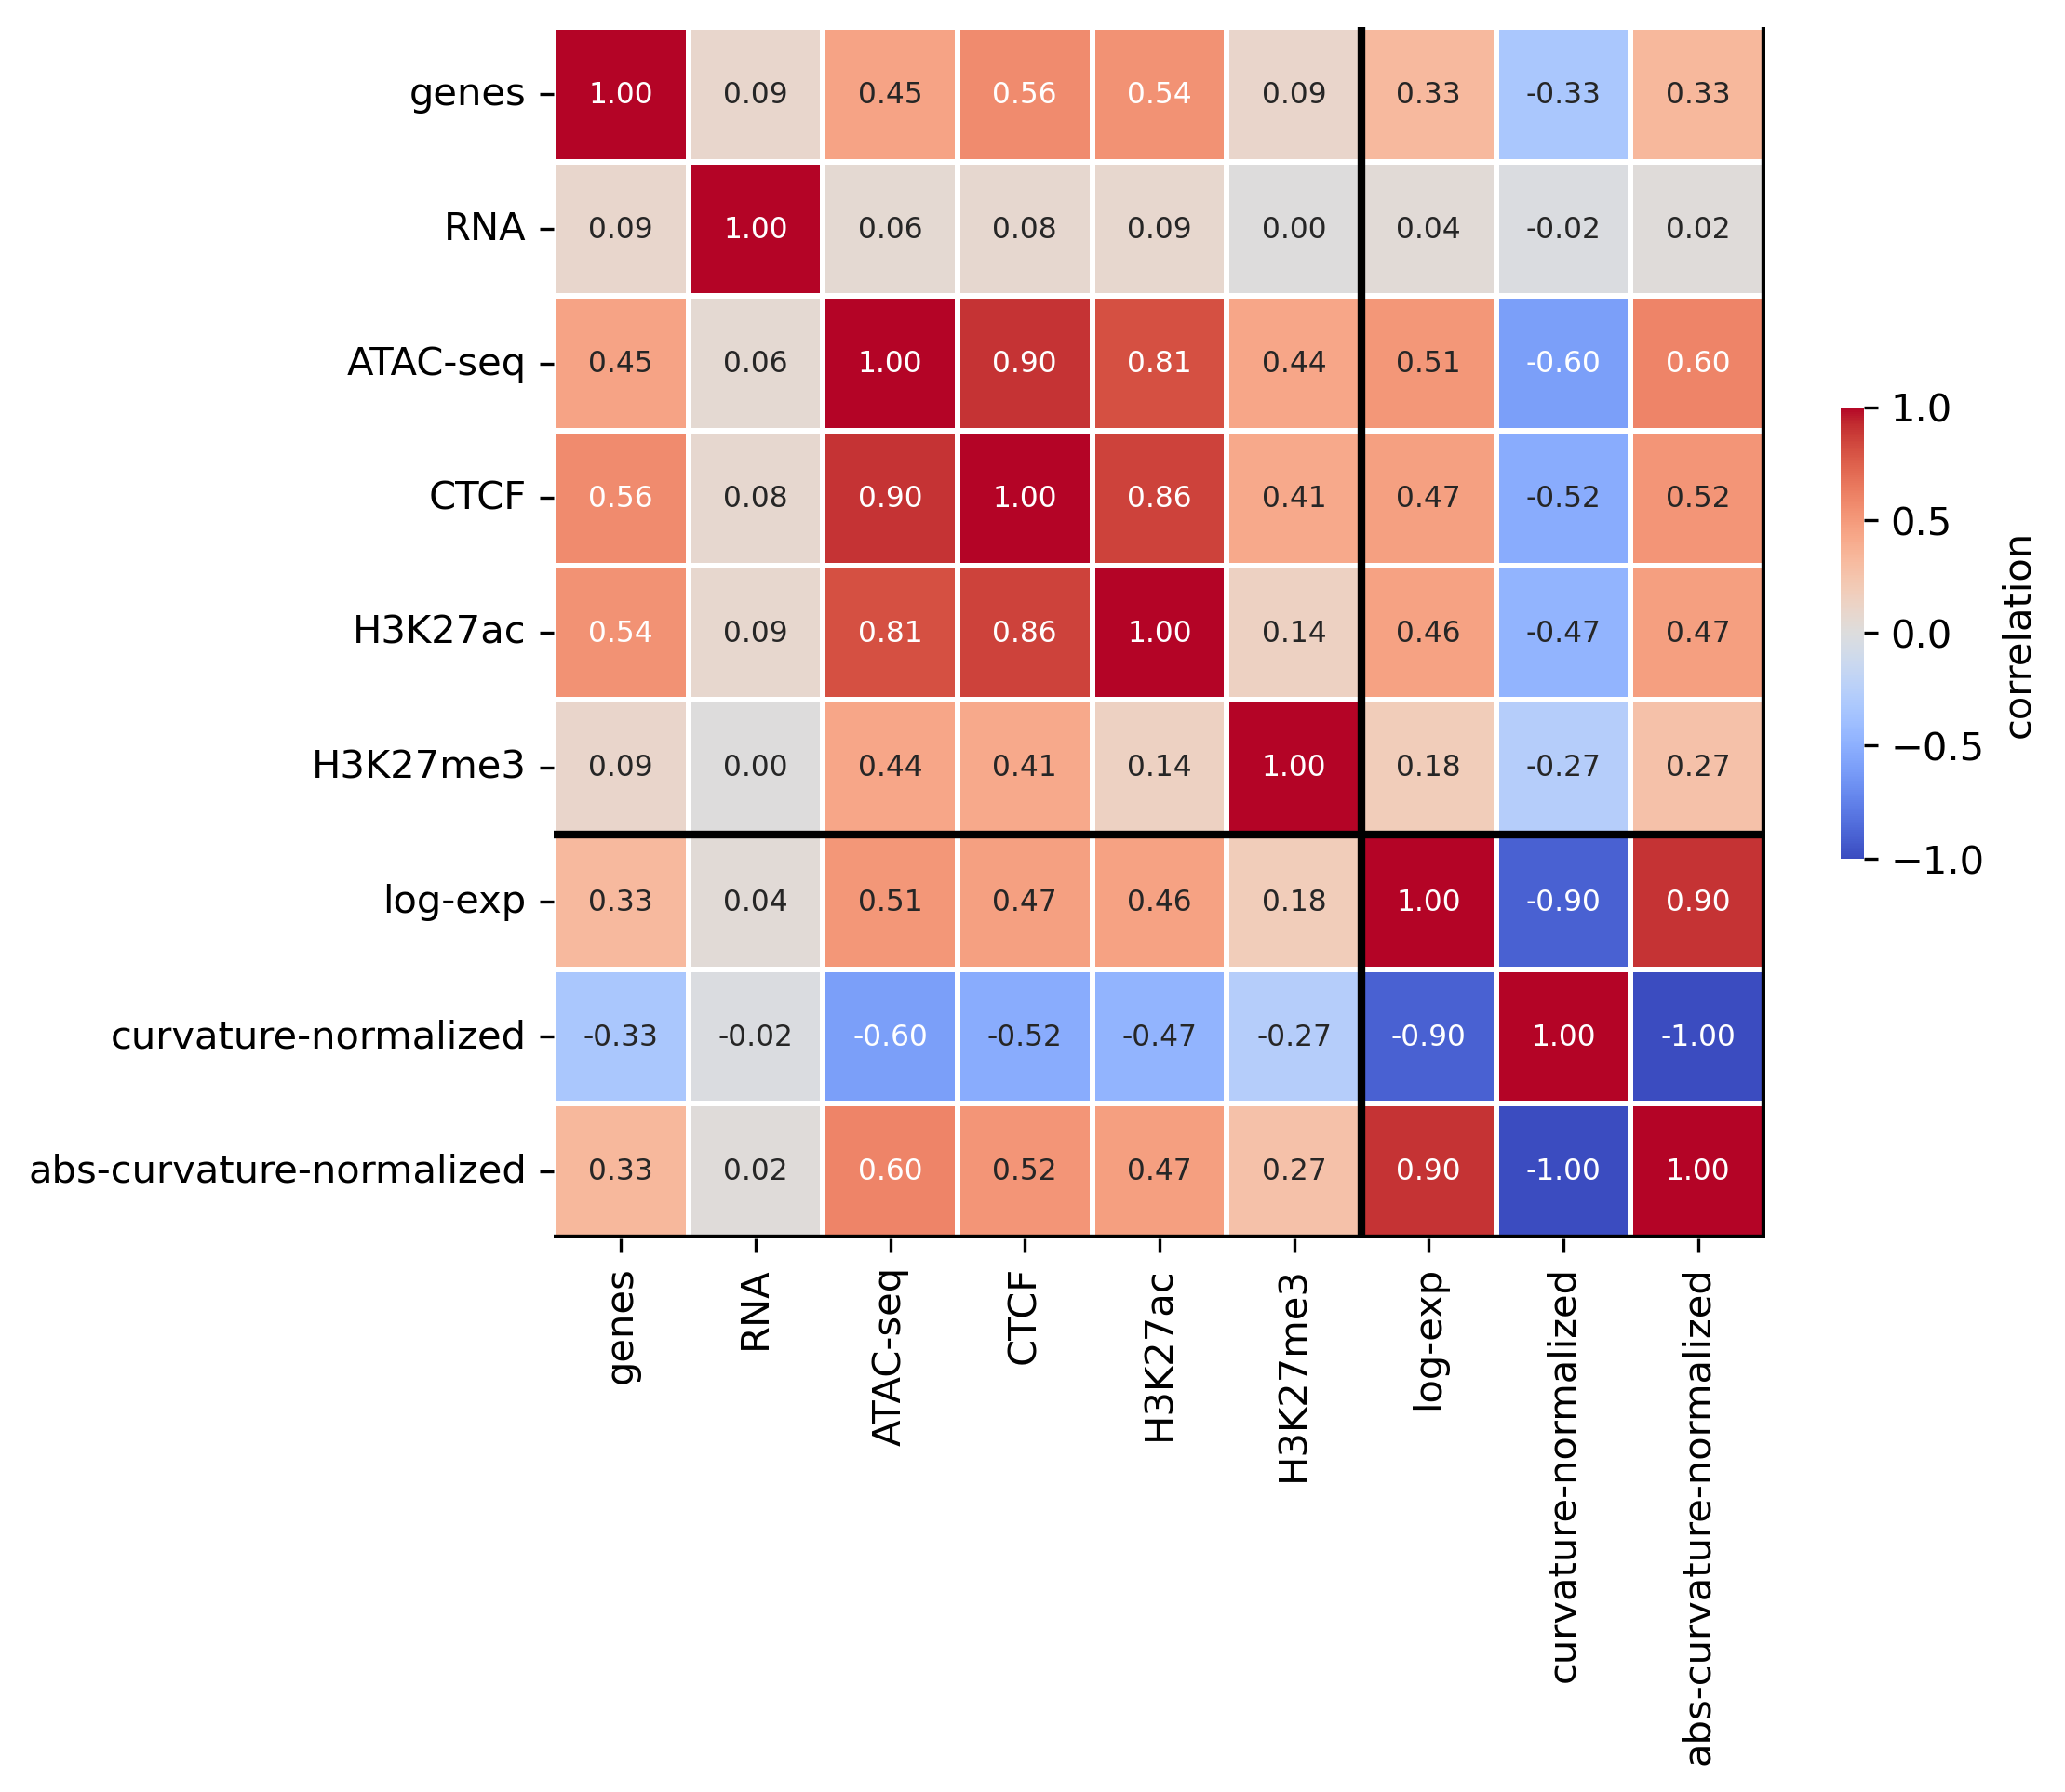

In [17]:
pdf = adata.obs.copy()

column_labels = {
    'n_genes': "genes",
    'RNA_5': "RNA",
    'ATACSeq_3': "ATAC-seq",
    'CTCF': "CTCF",
    'H3K27ac': "H3K27ac",
    'H3K27me3': "H3K27me3",
    #'ce_degree_centrality': "degree",
    #'ce_eigenvector_centrality': "eigenvector",
    #'ce_betweenness_centrality': "betweenness",
    # 'singular_vector_1': "singular vector",
    #'hge_linear_unweighted' : "linear",
    'global_hge_logexp_unweighted' : "log-exp",
    'normalized_scalar_curvature'  : "curvature-normalized",
    'abs_normalized_edge_curvature' : "abs-curvature-normalized",
    
    #'hge_logexp_RNA_weighted' : "log-exp (RNA)",
    #'hge_logexp_ATAC_weighted' : "log-exp (ATAC)",
}

corr = pdf[list(column_labels.keys())].corr()
corr.index = list(column_labels.values())
corr.columns = list(column_labels.values())

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 7

sns.heatmap(
    corr, 
    square=True,
    linewidths=1,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",  
    annot_kws={"size": 7.5},
    cbar_kws={'shrink': 0.3, 'label' : 'correlation'}
)

# Get the positions of the lines
# These positions are based on the order of your `column_labels`
lines = [6, 9,]

# Add vertical lines
for line in lines:
    plt.axvline(line, color='black', lw=2)
    plt.axhline(line, color='black', lw=2)

plt.show()